In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#import h5py

In [3]:
directory = "/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7424997/"
tree_name1 = "DetectorNeutrons"
tree_name2 = "Hits"
tree_name3 = "Primary"

pattern1 = f"{directory}/*.root:{tree_name1}"
pattern2 = f"{directory}/*.root:{tree_name2}"
pattern3 = f"{directory}/*.root:{tree_name3}"

dfs4 = []
dfs5 = []
dfs = []

print("Starting transfer of neutrons")
for chunk_dfs4 in uproot.iterate(pattern1,library="pd", step_size="250 MB"):
    dfs4.append(chunk_dfs4)
#print("neutrons complete, moving to hits")
#for chunk_dfs5 in uproot.iterate(pattern2,library="pd", step_size="250 MB"):
#    dfs5.append(chunk_dfs5)
print("hits complete, doing primaries")
for chunk_dfs in uproot.iterate(pattern3,library="pd", step_size="250 MB"):
    dfs.append(chunk_dfs)
print("transfer done, concatenating dataframes")
df4 = pd.concat(dfs4, ignore_index=True)
#print("done concat neutrons, concat hits")
#df5 = pd.concat(dfs5, ignore_index=True)
print("done concat hits, concat primaries")
df = pd.concat(dfs, ignore_index=True)
print("Done.")

#file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7104869/sum_neutron_planarsource.root")
#tree = file["Primary"]
#tree2 = file["WaterNeutrons"]
#tree3 = file["AirNeutrons"]
#tree4 = file["DetectorNeutrons"]
#tree5 = file["Hits"]

#df = tree.arrays(library="pd")
#df2 = tree2.arrays(library="pd")
#df3 = tree3.arrays(library="pd")
#df4 = tree4.arrays(library="pd")
#df5 = tree5.arrays(library="pd")

#df['ParticleName'] = df['ParticleName'].astype(str)


Starting transfer of neutrons
hits complete, doing primaries
transfer done, concatenating dataframes
done concat hits, concat primaries
Done.


In [4]:
#attempt to merge the primary energy here with the neutrons 
#merged_df = pd.merge(df2, df, on="EventID", how="inner")

#merged_df_fill = merged_df.fillna(method="ffill")
#print(merged_df_fill)

#merged_df2 = pd.merge(df3, df, on="EventID", how="inner")

#merged_df_fill2 = merged_df2.fillna(method="ffill")
#print(merged_df_fill2)

#merged_df3 = pd.merge(df3, df2, on="EventID", how="inner")
#merged_df_fill3 = merged_df3.fillna(method="ffill")
#print(merged_df_fill3)

print(df)
print(df4)

#merged_df4 = pd.merge(df4, df, on="EventID", how="inner")
merged_df4 = df.merge(df4, on=["EventID"], how="inner")
#print(merged_df4)

#merged_df_fill4 = merged_df4.fillna(method="ffill")
#print(merged_df_fill4)

#merged_df5 = pd.merge(df4, df5, on=["EventID"], how="inner")
#merged_df5 = df4.merge(df5, on=["EventID"], how="inner")
#merged_df_fill5 = merged_df5.fillna(method="ffill")
#print(merged_df5)

#merged_df5["ParticleName"] = merged_df5["ParticleName"].astype(str)

             EventID  TrackID  PDGCode  PrimaryEnergy  PrimaryPosX  \
0          2500000.0      1.0   2112.0      13.050098       -510.0   
1          2500001.0      1.0   2112.0     144.925321       -510.0   
2          2500002.0      1.0   2112.0     148.678518       -510.0   
3          2500003.0      1.0   2112.0      38.389444       -510.0   
4          2500004.0      1.0   2112.0     158.551095       -510.0   
...              ...      ...      ...            ...          ...   
94999995  24999995.0      1.0   2112.0     115.841411       -510.0   
94999996  24999996.0      1.0   2112.0      32.874398       -510.0   
94999997  24999997.0      1.0   2112.0      94.421541       -510.0   
94999998  24999998.0      1.0   2112.0      51.074725       -510.0   
94999999  24999999.0      1.0   2112.0     104.181890       -510.0   

          PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0         -323.797892   419.826021          0.546411          0.039247   
1          

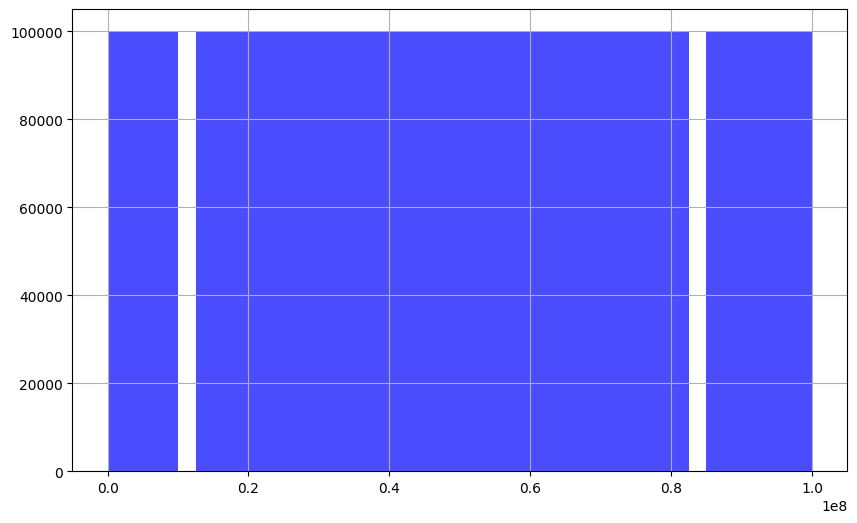

In [77]:
plt.figure(figsize=(10, 6))
plt.hist(df['EventID'], bins=1000, color='blue', alpha=0.7)
#plt.title('Neutron Energy at boundary of lead/water shield')
#plt.xlabel('Neutron Energy (MeV)')
#plt.ylabel('Frequency')
plt.grid()
#plt.savefig("250kneutron_fullDetector_NRDistro.pdf")
plt.show()



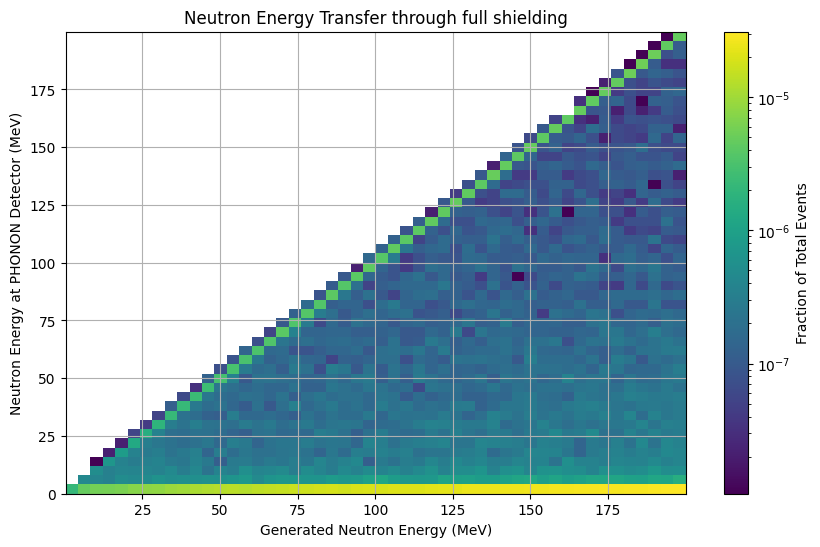

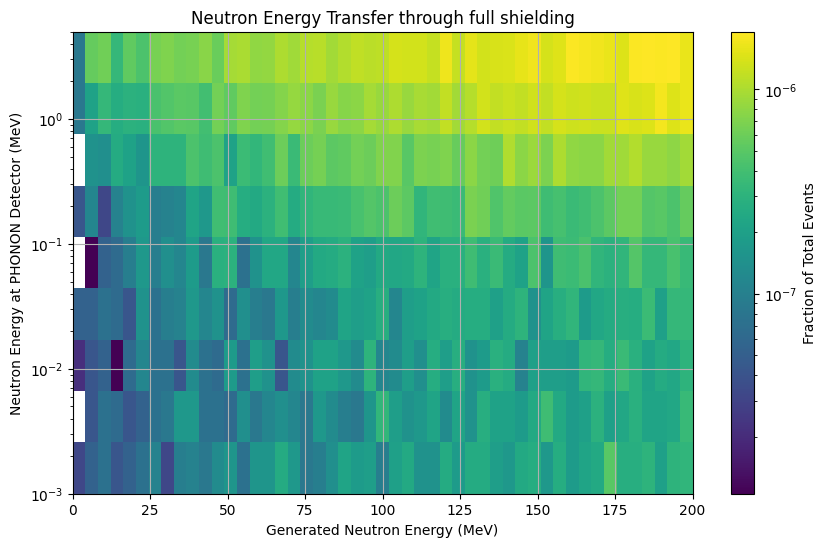

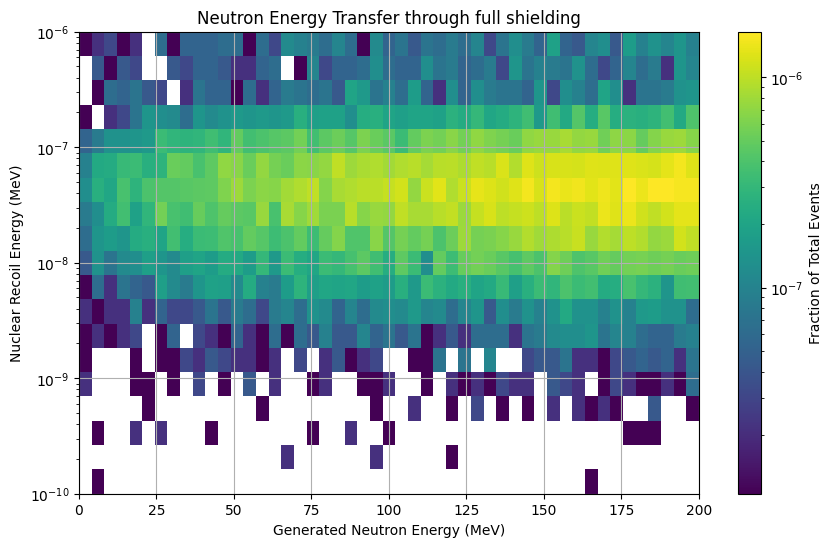

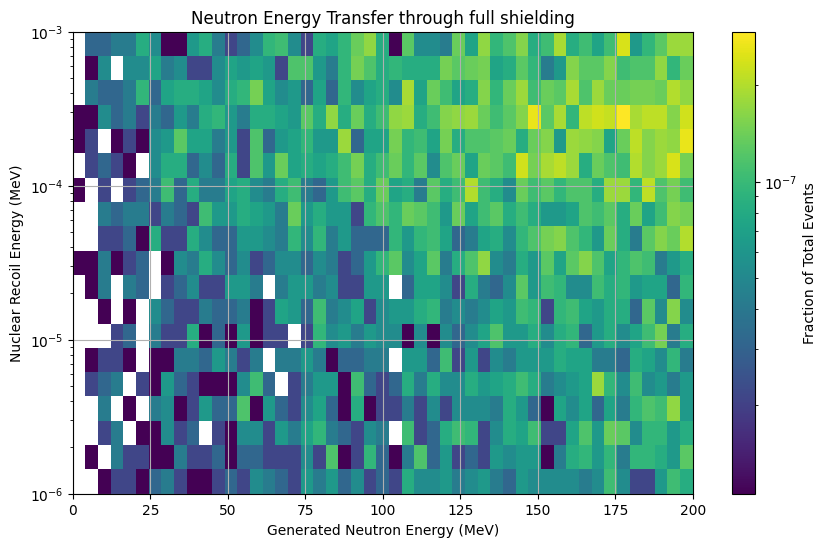

In [22]:
from matplotlib.colors import LogNorm
'''
heatmap, xedges, yedges = np.histogram2d(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through lead shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at lead/water shield boundary')
plt.grid()
plt.savefig("NeutronTransfer_LeadWaterBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through water shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.savefig("NeutronTransfer_WaterFridgeBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill3['KineticEnergy_x'], merged_df_fill3['KineticEnergy_y'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function between shielding layers')
plt.xlabel('Neutron Energy at lead/water shield boundary')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.show()
'''
#prim_mask = (merged_df4['TrackID_y'] == 1)

#prim_merged_df4 = merged_df4[prim_mask]
'''
heatmap, xedges, yedges = np.histogram2d(merged_df4['PrimaryEnergy_x'], merged_df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 95000000
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
#plt.scatter(merged_df4['PrimaryEnergy'], merged_df4['KineticEnergy'], alpha=0.5, s=1)
#plt.imshow(merged_df4['PrimaryEnergy'], merged_df4['KineticEnergy'])
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.grid()
#plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_planarneutrons_FracColorBar.pdf")
plt.show()
'''
heatmap, xedges, yedges = np.histogram2d(df4['PrimaryEnergy'], df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.grid()
plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_planarneutrons_FracColorBar.pdf")
plt.show()

bins_x = np.linspace(0,200,num=50)

min = np.min(0.001)
max = np.max(5)
bins_y = np.logspace(np.log10(min), np.log10(max), num=10)

heatmap, xedges, yedges = np.histogram2d(df4['PrimaryEnergy'], df4['KineticEnergy'], bins=[bins_x, bins_y])
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.yscale('log')
plt.grid()
plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_lowenergy_planarneutrons_FracColorBar.pdf")
plt.show()

mask = df['totalNR'] < 1e-6
df_masked = df[mask]
#print(df_masked)
bins_y = np.logspace(np.log10(1e-10), np.log10(1e-6), num=20)

heatmap, xedges, yedges = np.histogram2d(df_masked['PrimaryEnergy'], df_masked['totalNR'], bins=[bins_x, bins_y])
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Nuclear Recoil Energy (MeV)')
plt.yscale('log')
plt.grid()
plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_lessthaneV_planarneutrons_FracColorBar.pdf")
plt.show()

mask = df['totalNR'] < 1e-3
df_masked = df[mask]
#print(df_masked)
bins_y = np.logspace(np.log10(1e-6), np.log10(1e-3), num=20)

heatmap, xedges, yedges = np.histogram2d(df_masked['PrimaryEnergy'], df_masked['totalNR'], bins=[bins_x, bins_y])
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Nuclear Recoil Energy (MeV)')
plt.yscale('log')
plt.grid()
plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_eVtokeV_planarneutrons_FracColorBar.pdf")
plt.show()

In [ ]:
#generate binning in same way as above plot for primary energy to setup looking for hits in the scintillator 
#do for both overall neutrons and neutrons that enter the detector
#Look for both hits in 0-150 keV individually and also total NR for LiNbO3 block events
bins_num = 50
Emin, Emax = df['PrimaryEnergy'].min(), df['PrimaryEnergy'].max()
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(counts_den)
print(edges)

bin_centers = (edges[:-1] + edges[1:]) / 2.0

new_counts, _ = np.histogram(df4['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts, counts_den)
print(eff_vals)

plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to reach substrate")
plt.grid()
plt.savefig("test_efficiency_wafers_substrate_morestats.pdf")
plt.show()

[ 1  6  7 13 10 10 16 20  5 22 10 18 17 16 18  7 18 18 19 18 14 17 30 22
 23 26 35 25 19 24 26 33 27 28 21 36 21 33 32 37 31 27 25 43 34 23 27 36
 34 36]


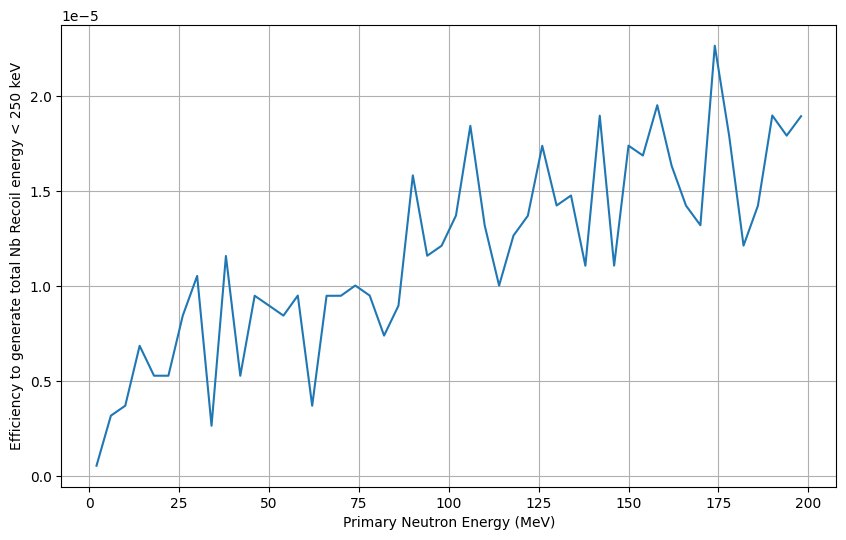

[  30   91  126  278  323  439  615  701  772  737 1036  866  708 1021
 1023  803 1225 1173 1039  967 1155 1319 1395 1194 1255 1372 1726 1379
 1225 1475 1836 1618 1408 1433 1953 1943 2068 1723 1782 2053 1901 1903
 2011 2374 1945 2204 2096 2813 2192 2509]


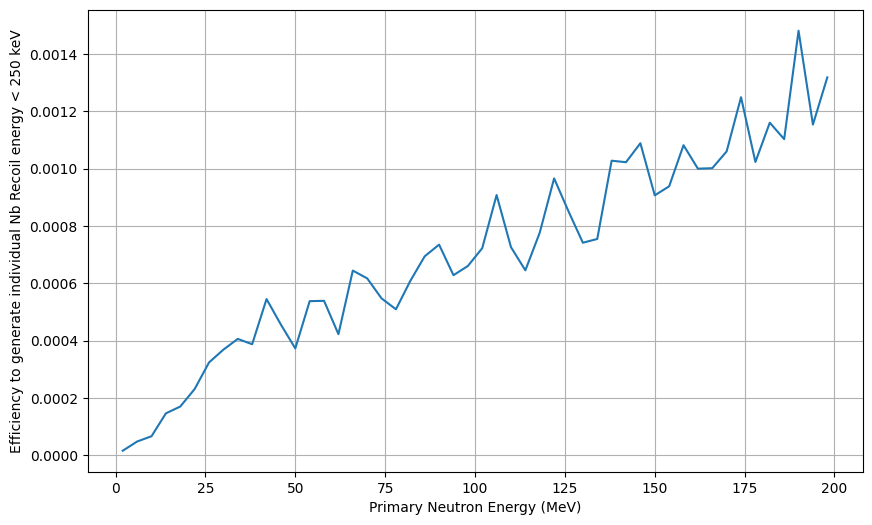

In [15]:
mask_nb = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False)
mask_nr = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False) | merged_df5["ParticleName"].str.contains('Li', case=False, na=False) | merged_df5["ParticleName"].str.contains('O', case=False, na=False)
nb_recoil_df = merged_df5[mask_nb]
nr_recoil_df = merged_df5[mask_nr]

mask_nb_roi = (merged_df5["Edep"] > 0.001) & (merged_df5["Edep"] < 0.25)

nb_roi_df = merged_df5[mask_nb_roi]
nr_roi_df = merged_df5[mask_nb_roi]

mask_nb_total = (merged_df4["totalNb"] > 0.001) & (merged_df4["totalNb"] < 0.25)
mask_nr_total = (merged_df4["totalNR"] > 0.001) & (merged_df4["totalNR"] < 0.25)

total_nb_df = merged_df4[mask_nb_total]
total_nr_df = merged_df4[mask_nr_total]

#attempt to create efficiency plot for neutrons generating Nb recoils of < 150 keV, both total and individual
new_counts, _ = np.histogram(total_nb_df['PrimaryEnergy_x'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts,counts_den)
plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to generate total Nb Recoil energy < 250 keV")
plt.grid()
plt.savefig("efficiency_wafers_substrate_Nb_recoils_morestats.pdf")
plt.show()

new_counts, _ = np.histogram(nb_roi_df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts,counts_den)
plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to generate individual Nb Recoil energy < 250 keV")
plt.grid()
plt.savefig("efficiency_wafers_substrate_individual_Nb_recoils_morestats.pdf")
plt.show()




/tmp/ipykernel_1967439/2885172683.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_nb_df["selected"] = pd.cut(total_nb_df["PrimaryEnergy_x"], bins=edges)
/tmp/ipykernel_1967439/2885172683.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, group in total_nb_df.groupby("selected"):


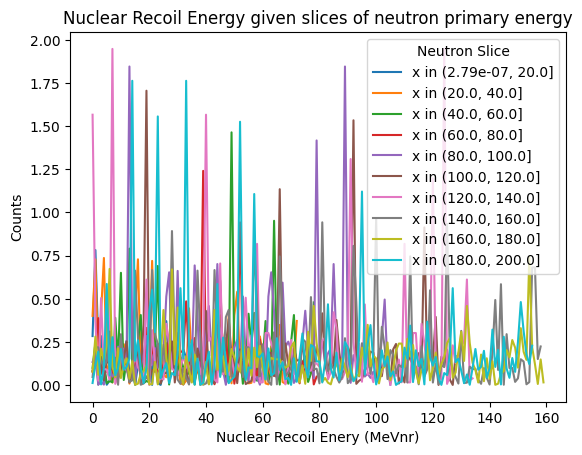

In [20]:
#plot total and individual recoil energy for given neutron primary energy
bins_num = 10
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))

total_nb_df["selected"] = pd.cut(total_nb_df["PrimaryEnergy_x"], bins=edges)
for b, group in total_nb_df.groupby("selected"):
    plt.plot(group["totalNR"].values, linestyle='-', label=f"x in {b}")
plt.xlabel("Nuclear Recoil Enery (MeVnr)")
plt.ylabel("Counts")
plt.title("Nuclear Recoil Energy given slices of neutron primary energy")
plt.legend(title="Neutron Slice")
plt.savefig("primary_neutron_slices_nrenergy.pdf")
plt.show()

In [5]:
def create_weights(counts_num, counts_den, edges, smooth=1e-12, clip=None, norm=""):
    denom = counts_den.astype(float)
    num = counts_num.astype(float)
    w = np.divide(num, denom, out=None, where=True)
    #w = np.divide(num, denom)
    if clip is not None:
        lo, hi = clip
        w = np.clip(w, lo, hi)
    if norm == "mean1":
        m = w.mean()
        if m > 0: w = w/m
    if norm == "sum1":
        s = w.sum()
        if s > 0: w = w/s
    return edges, w

def apply_weights(xs, edges, weights, underflow="extend", overflow="extend", default=1.0):
    xs = np.asarray(xs)
    idx = np.digitize(xs, edges, right=True) - 1 #creates a set from 0 to nbins-1
    nan_mask = ~np.isfinite(xs)
    idx = np.where(nan_mask, -1, idx)
    out = np.where(idx == -1, default, weights[idx])
    return out

In [6]:
#reweight on the neutrons by defining the power law, start with a area normalized version that I can scale by the actual flux value
#range is in MeV, flux value in something like n/MeV/m^2/us(spill) so I can normalize by the plane area and the time unit

def power_law(a, bins=100, rng=(0.01,200.0),density=False):
    lower_bound, upper_bound = float(rng[0]), float(rng[1])
    if upper_bound < lower_bound:
        raise ValueError("Upper bound must be greater than lower bound!")
    if isinstance(bins,int):
        edges = np.linspace(lower_bound, upper_bound, bins+1)
    else:
        edges = np.asarray(bins, dtype=float)
        if not np.all(np.diff(edges) > 0):
            raise ValueError("bin values must strictly increase!")
    widths = np.diff(edges)
    
    #compute the histogram
    pow_val = a + 1.0
    if lower_bound == 0 and a < -1:
        raise ValueError("cannot include lower_bound = 0 for a < -1 in this instance!")
    val_hi = edges[1:]**pow_val
    val_lo = edges[:-1]**pow_val
    denom = (upper_bound**pow_val) - (lower_bound**pow_val)
    prob = (val_hi - val_lo)/denom
    
    if density:
        hist = prob/widths
    else:
        hist = prob
    
            
    return hist, edges 

0.9999999999999999


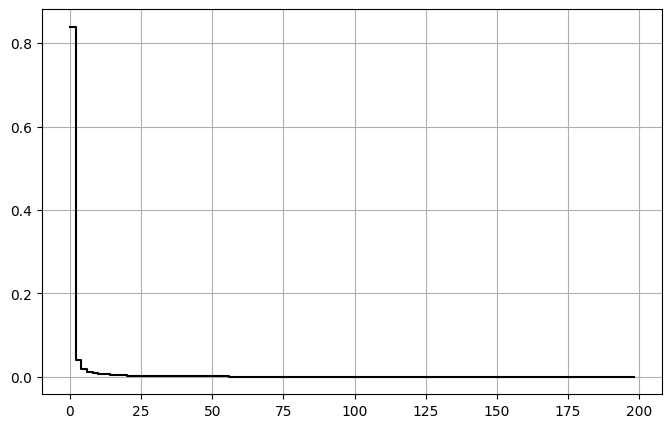

In [26]:
#generate normalized power law
h, e = power_law(-1.3)
#print(h)
print(np.sum(h))
#attempt a random scaling to check that as a concept, it works
#h = h * 1e3
plt.figure(figsize=(8,5))
plt.step(e[:-1], h, where="post", color="black")
plt.grid()
plt.savefig("example_power_law_weighting.pdf")
plt.show()

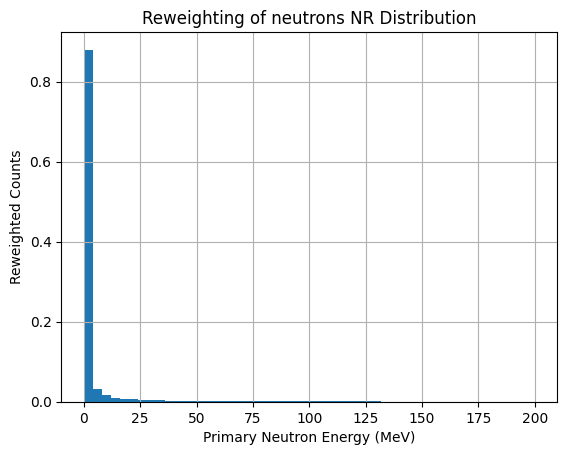

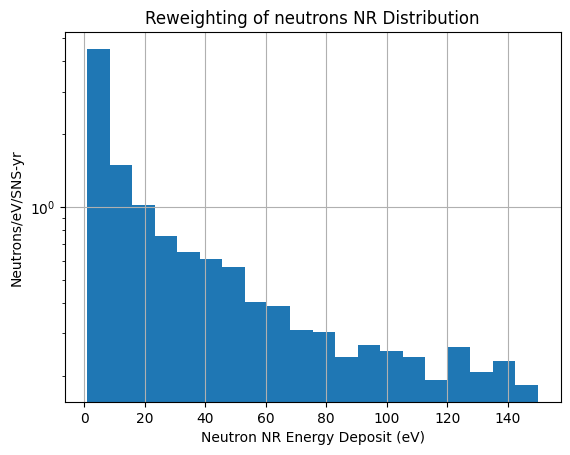

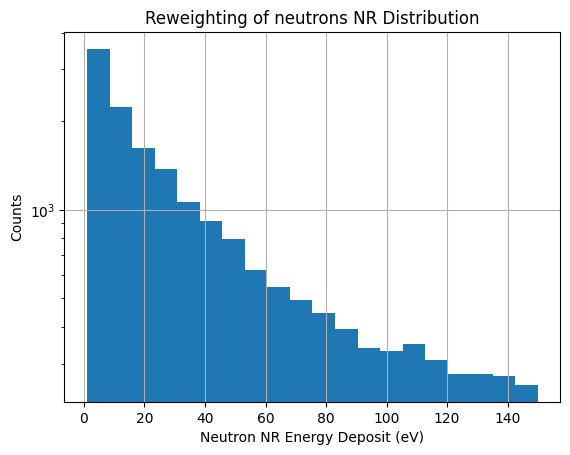

In [27]:
#with flux value from 2.5-40 MeV neutrons, restrict to that for now since we have defined flux
#mask_neutrons = (df_neutron['PrimaryEnergy'] > 2.5) & (df_neutron['PrimaryEnergy'] < 40.0)
#df_neutron_mask = df_neutron[mask_neutrons]

#now attempt a weighting with this using the original primaries
Emin, Emax = e.min(), e.max()
counts_den_neutron, edges_neutron = np.histogram(df['PrimaryEnergy'], bins=100, range=(Emin, Emax))
#generate weighting
fin_edges_neutron, weights_neutron = create_weights(h, counts_den_neutron, edges_neutron)

df['weights'] = apply_weights(df['PrimaryEnergy'], fin_edges_neutron, weights_neutron)
#merged_hits_neutrons['weights'] = apply_weights(merged_hits_neutrons['PrimaryEnergy'], fin_edges_neutron, weights_neutron)
#print(merged_hits_neutrons)
#this way works as I would expect, need to explore the merged dataframe better and understand that it is actually doing what I want
#with the stored weights it should be extendable to any variable that has the primary energy, might check that in each case common values give the same weight
plt.hist(df['PrimaryEnergy'], bins=50, range=(0.01, 200), weights=df['weights'])
plt.xlabel('Primary Neutron Energy (MeV)')
plt.ylabel('Reweighted Counts')
plt.title('Reweighting of neutrons NR Distribution')
#plt.yscale('log')
#plt.xscale('log')
plt.grid()
#plt.savefig('CEvNS_Reweighted_test_spectrum.pdf')
plt.show()

#mask = merged_hits_neutrons["totalNR"] > 0.0
#df_mask = merged_hits_neutrons[mask]

#scale the weights in order to get a full flux value
area = 1 #1 m^2 planar source
MWhr_per_yr = 7000 #assume 5000 hrs at 1.4 MW as in dukecevns calc
total_flux = 20 #in n/m^2/MWhr over the 2.5-40 MeV neutron energy range
df['weights'] = df['weights']*total_flux*area*MWhr_per_yr #convert to neutrons/SNS-year

#compute scale factor for /keV
bins_val = 20
lo, hi = 1, 150
width = (hi-lo)/(bins_val*1.0)
per_keV = width #convert to per keV

df['weights'] = df['weights']*per_keV

plt.hist(df['totalNR']*1e3, bins=20, range=(1,150), weights=df['weights'])
plt.xlabel('Neutron NR Energy Deposit (eV)')
plt.ylabel('Neutrons/eV/SNS-yr')
plt.title('Reweighting of neutrons NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Neutrons_weighted_LiNbO3_spectrum_eVscale.pdf')
plt.show()

plt.hist(df['totalNR']*1e3, bins=20, range=(1,150))
plt.xlabel('Neutron NR Energy Deposit (eV)')
plt.ylabel('Counts')
plt.title('Reweighting of neutrons NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Neutrons_unweighted_LiNbO3_spectrum_eVscale.pdf')
plt.show()





In [60]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7465783/sum_cevns_full.root")
tree = file["Primary"]
tree5 = file["Hits"]

df_n = tree.arrays(library="pd")

In [24]:
data_cevns = np.loadtxt("/N/project/phonon/jczettle/dukecevns-wdir/dukecevns-assumptions/out/eVscale/sns_diff_rates_alliso-LiNbO-LiNbO-klein.out")
rec_energy = data_cevns[:,0]*1e3
#convert to counts per eV
counts = data_cevns[:,1]/1e3
bins_num = len(rec_energy)
counts_cevns, bin_edges = np.histogram(rec_energy, bins=bins_num, weights=counts)

print("Histogram values:", counts_cevns)
print("Bin edges:", bin_edges)

Histogram values: [1.26567e+01 1.26544e+01 1.26487e+01 ... 4.79960e-07 4.79958e-07
 4.79956e-07]
Bin edges: [1.00000000e-03 1.99999881e-03 2.99999762e-03 ... 8.40859000e+02
 8.40860000e+02 8.40861000e+02]


In [25]:
Emin, Emax = rec_energy.min(), rec_energy.max()
counts_den, edges = np.histogram(df_n['PrimaryEnergy']*1e3, bins=bins_num, range=(Emin, Emax))
print(counts_den)

fin_edges, weights = create_weights(counts_cevns, counts_den, edges)

df_n['weights'] = apply_weights(df_n['PrimaryEnergy']*1e3, fin_edges, weights)

mask_total_test = df_n["totalNR"]*1e3 > 0.1

masked_df_total = df_n[mask_total_test]

plt.hist(masked_df_total['totalNR']*1e3, bins=bins_num, weights=masked_df_total['weights'])
plt.xlabel('Total NR Energy Deposit (eV)')
plt.ylabel('Weighted Counts')
plt.title('Reweighting of CEvNS NR Distribution')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig('CEvNS_Reweighted_150eV_spectrum.pdf')
plt.show()

[52 53 47 ...  0  0  0]


/tmp/ipykernel_374919/3353406073.py:4: RuntimeWarning: divide by zero encountered in divide
  w = np.divide(num, denom, out=None, where=True)


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/N/project/phonon/jczettle/python_env/lib64/python3.11/site-packages/matplotlib/cbook.py", line 2055, in _setattr_cm
    yield
  File "/N/project/phonon/jczettle/python_env/lib64/python3.11/site-packages/matplotlib/backend_bases.py", line 2186, in print_figure
    result = print_method(
             ^^^^^^^^^^^^^
  File "/N/project/phonon/jczettle/python_env/lib64/python3.11/site-packages/matplotlib/backend_bases.py", line 2042, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
                                                                 ^^^^^
  File "/N/project/phonon/jczettle/python_env/lib64/python3.11/site-packages/matplotlib/backends/backend_pdf.py", line 2786, in print_pdf
    self.figure.draw(renderer)
  File "/N/project/phonon/jczettle/python_env/lib64/python3.11/site-packages/matplotlib/artist.py", line 94, in draw_wrapper
    result = draw(artist, renderer, *args, **kwargs)
             ^^^^^^^^^^

Error in callback <function flush_figures at 0x7fa6bc20b4c0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [28]:
#number of events in signal/background greater than 10 eV (set 150 keV max)
cond_nu = df_n['totalNR']*1e3 > 0.01 
cond_nu2 = df_n['totalNR']*1e3 < 150
cond_n = df['totalNR']*1e3 > 0.01
cond_n2 = df['totalNR']*1e3 < 150

signal = df_n[cond_nu & cond_nu2]['weights'].sum()
print(f"Signal Events: {signal}")
background = df[cond_n & cond_n2]['weights'].sum()
print(f"Background Events: {background}")
snr = signal/background
print(f"Signal to Noise for 10 eV threshold: {snr}")

#number of events in signal/background greater than 100 eV (set 150 keV max)
cond_nu = df_n['totalNR']*1e3 > 0.1 
cond_nu2 = df_n['totalNR']*1e3 < 150
cond_n = df['totalNR']*1e3 > 0.1
cond_n2 = df['totalNR']*1e3 < 150

signal = df_n[cond_nu & cond_nu2]['weights'].sum()
print(f"Signal Events: {signal}")
background = df[cond_n & cond_n2]['weights'].sum()
print(f"Background Events: {background}")
snr = signal/background
print(f"Signal to Noise for 100 eV threshold: {snr}")

#number of events in signal/background greater than 1000 eV (set 150 keV max)
cond_nu = df_n['totalNR']*1e3 > 1 
cond_nu2 = df_n['totalNR']*1e3 < 150
cond_n = df['totalNR']*1e3 > 1
cond_n2 = df['totalNR']*1e3 < 150

signal = df_n[cond_nu & cond_nu2]['weights'].sum()
print(f"Signal Events: {signal}")
background = df[cond_n & cond_n2]['weights'].sum()
print(f"Background Events: {background}")
snr = signal/background
print(f"Signal to Noise for 1 keV threshold: {snr}")

Signal Events: 132306.2416579
Background Events: 16.302642221750766
Signal to Noise for 10 eV threshold: 8115.631801167716
Signal Events: 131171.7593579
Background Events: 15.05101417125407
Signal to Noise for 100 eV threshold: 8715.14423316569
Signal Events: 120312.8981579
Background Events: 13.08344055351259
Signal to Noise for 1 keV threshold: 9195.81494376866


/tmp/ipykernel_1967439/1311145403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  masked_df_total['weights'] = masked_df_total['weights']*(per_keV/10.0) #scale to the bin width so it is still /keV and I retain the ~right integral


0.745


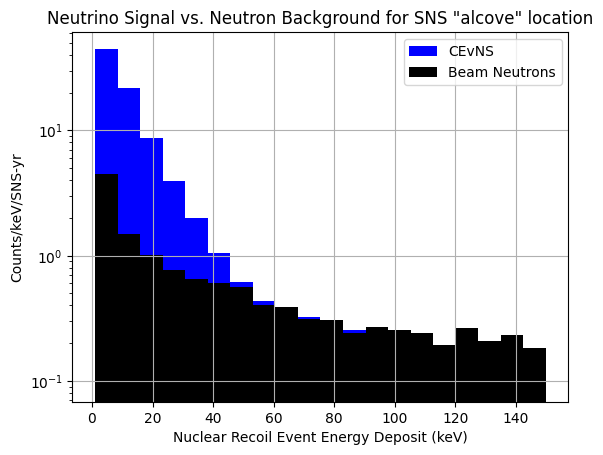

In [72]:
masked_df_total['weights'] = masked_df_total['weights']*(per_keV/10.0) #scale to the bin width so it is still /keV and I retain the ~right integral
print(per_keV/10.0)
plt.hist(masked_df_total['totalNR']*1e3, bins=20, range=(1,150), label="CEvNS", color='blue', weights=masked_df_total['weights'])
plt.hist(df['totalNR']*1e3, bins=20, range=(1,150), label="Beam Neutrons", color='black', weights=df['weights'])
plt.xlabel('Nuclear Recoil Event Energy Deposit (eV)')
plt.ylabel('Counts/eV/SNS-yr')
plt.title('Neutrino Signal vs. Neutron Background for SNS "alcove" location')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('UpdatedCEvNSNeutrons_AlcoveReweighting_eVscale.pdf')
plt.show()

/tmp/ipykernel_374919/2266333732.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  masked_df_total['HBARphononsNR'] = masked_df_total['totalNR']/debye_to_meV*1e9*debye_to_HBAR


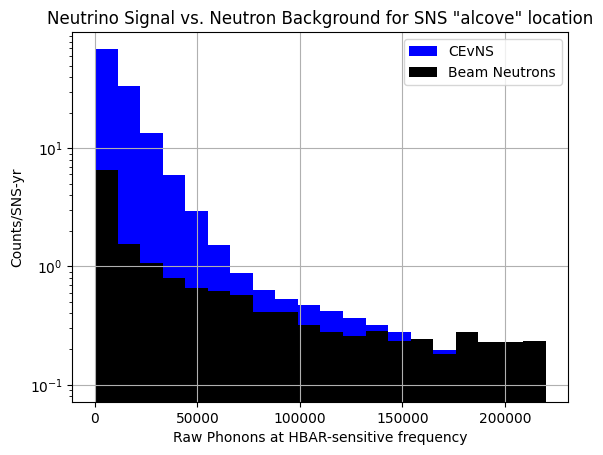

In [36]:
#convert to raw phonons at HBAR frequency
debye_to_meV = 48.34 #convert Debye frequency to energy in meV
debye_to_HBAR = 0.07 #fraction of Debye phonons that produce a phonon at the HBAR frequency (4 +/- 0.01 GHz) 
#create dataframe entry for the totalNR energy converted into phonons and plot

masked_df_total['HBARphononsNR'] = masked_df_total['totalNR']/debye_to_meV*1e9*debye_to_HBAR
df['HBARphononsNR'] = df['totalNR']/debye_to_meV*1e9*debye_to_HBAR
bin_width = (100000.0-100.0)/20.0

cond_nu = masked_df_total['HBARphononsNR'] > 100 
cond_nu2 = masked_df_total['HBARphononsNR'] < 220000

weighting = (132/masked_df_total[cond_nu & cond_nu2]['weights'].sum())

plt.hist(masked_df_total['HBARphononsNR'], bins=20, range=(100,220000), label="CEvNS", color='blue', weights=masked_df_total['weights']*weighting)
plt.hist(df['HBARphononsNR'], bins=20, range=(100,220000), label="Beam Neutrons", color='black', weights=df['weights'])
plt.xlabel('Raw Phonons at HBAR-sensitive frequency')
plt.ylabel('Counts/SNS-yr')
plt.title('Neutrino Signal vs. Neutron Background for SNS "alcove" location')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('UpdatedCEvNSNeutrons_AlcoveReweighting_phononscale.pdf')
plt.show()


In [61]:
data_cevns = np.loadtxt("/N/project/phonon/jczettle/dukecevns-wdir/dukecevns-assumptions/out/eVscale/reactor_diff_rates_alliso-LiNbO-LiNbO-klein.out")
rec_energy = data_cevns[:,0]*1e6
#convert to counts per eV
counts = data_cevns[:,1]/1e6
bins_num = len(rec_energy)
counts_cevns, bin_edges = np.histogram(rec_energy, bins=bins_num, weights=counts)

print("Histogram values:", counts_cevns)
print("Bin edges:", bin_edges)

Histogram values: [6.41077e+02 5.79175e+02 5.36814e+02 ... 6.47766e-09 4.31654e-09
 1.07870e-09]
Bin edges: [1.00000000e+00 1.99994883e+00 2.99989766e+00 ... 1.95400001e+04
 1.95410001e+04 1.95420000e+04]


[211 226 204 ...   0   0   0]


/tmp/ipykernel_374919/3353406073.py:4: RuntimeWarning: divide by zero encountered in divide
  w = np.divide(num, denom, out=None, where=True)


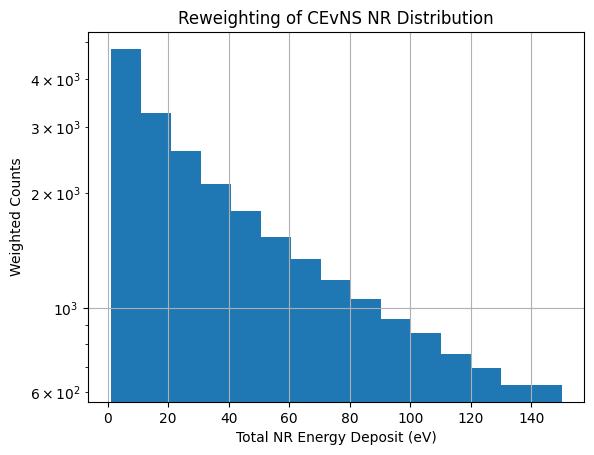

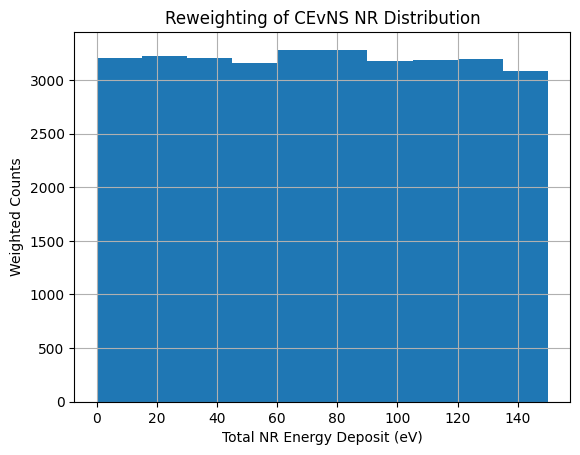

In [62]:
Emin, Emax = rec_energy.min(), rec_energy.max()
counts_den, edges = np.histogram(df_n['PrimaryEnergy']*1e6, bins=bins_num, range=(Emin, Emax))
print(counts_den)

fin_edges, weights = create_weights(counts_cevns, counts_den, edges)

df_n['weights'] = apply_weights(df_n['PrimaryEnergy']*1e6, fin_edges, weights)

mask_total_test = df_n["totalNR"]*1e6 > 0.1

masked_df_total = df_n[mask_total_test]

plt.hist(masked_df_total['totalNR']*1e6, bins=15, range=(1,150), weights=masked_df_total['weights'])
plt.xlabel('Total NR Energy Deposit (eV)')
plt.ylabel('Weighted Counts')
plt.title('Reweighting of CEvNS NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Reactor_CEvNS_Reweighted_150eV_spectrum.pdf')
plt.show()

plt.hist(masked_df_total['totalNR']*1e6)
plt.xlabel('Total NR Energy Deposit (eV)')
plt.ylabel('Weighted Counts')
plt.title('Reweighting of CEvNS NR Distribution')
#plt.yscale('log')
#plt.xscale('log')
plt.grid()
#plt.savefig('Reactor_CEvNS_Reweighted_150eV_spectrum.pdf')
plt.show()

In [39]:
directory = "/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7614208/"
tree_name1 = "DetectorGammas"
tree_name2 = "Hits"
tree_name3 = "Primary"

pattern1 = f"{directory}/gamma_spectrum_0*.root:{tree_name1}"
pattern2 = f"{directory}/gamma_spectrum_0*.root:{tree_name2}"
pattern3 = f"{directory}/gamma_spectrum_0*.root:{tree_name3}"

dfs4 = []
dfs5 = []
dfs = []

print("Starting transfer of neutrons")
for chunk_dfs4 in uproot.iterate(pattern1,library="pd", step_size="250 MB"):
    dfs4.append(chunk_dfs4)
print("neutrons complete, moving to hits")
for chunk_dfs5 in uproot.iterate(pattern2,library="pd", step_size="250 MB"):
    dfs5.append(chunk_dfs5)
print("hits complete, doing primaries")
for chunk_dfs in uproot.iterate(pattern3,library="pd", step_size="250 MB"):
    dfs.append(chunk_dfs)
print("transfer done, concatenating dataframes")
df4 = pd.concat(dfs4, ignore_index=True)
print("done concat neutrons, concat hits")
df5 = pd.concat(dfs5, ignore_index=True)
print("done concat hits, concat primaries")
df = pd.concat(dfs, ignore_index=True)
print("Done.")

Starting transfer of neutrons
neutrons complete, moving to hits
hits complete, doing primaries
transfer done, concatenating dataframes
done concat neutrons, concat hits
done concat hits, concat primaries
Done.


In [40]:
gamma_rates = np.loadtxt("/N/project/phonon/jczettle/HFIR_gamma.txt", delimiter=',')
energy = gamma_rates[:,0]
#extract gamma rates
rate = gamma_rates[:,1]
bins_num = len(rate)
rate_gamma, bin_edges = np.histogram(energy, bins=bins_num, weights=rate)

print("Histogram values:", rate_gamma)
print("Bin edges:", bin_edges)

Histogram values: [2.08487147e+02 1.21844274e+02 1.80571550e+02 1.35643504e+02
 1.83524781e+02 7.12583504e+01 5.95908129e+01 4.98336682e+01
 4.16741165e+01 3.61194592e+01 5.48212950e+01 2.71325688e+01
 1.43903913e+02 4.96720752e+01 7.22492182e+00 1.03287865e+01
 3.79550805e+00 0.00000000e+00 2.85114688e+00 2.06651220e+00
 0.00000000e+00 1.66744005e+00 0.00000000e+00 1.25256393e+00
 1.08561226e+00 9.07858752e-01 7.86852124e-01 0.00000000e+00
 6.81974221e-01 6.12595900e-01 5.70310680e-01 5.30944251e-01
 5.30944251e-01 4.94295141e-01 4.60175782e-01 4.44009711e-01
 4.44009711e-01 4.44009711e-01 3.84828568e-01 0.00000000e+00
 3.84828568e-01 0.00000000e+00 3.84828568e-01 3.33535559e-01
 0.00000000e+00 3.21818385e-01 0.00000000e+00 3.21818385e-01
 0.00000000e+00 2.78923874e-01 0.00000000e+00 3.10512838e-01
 0.00000000e+00 0.00000000e+00 2.69125220e-01 0.00000000e+00
 2.99604457e-01 0.00000000e+00 2.33254072e-01 2.33254072e-01
 0.00000000e+00 2.41746683e-01 2.33254072e-01 2.33254072e-01
 2.171

[1026398 1024822 1025292 1026915 1024598 1026699 1026413 1026421 1025580
 1027645 1026625 1026067 1025955 1025253 1026986 1026158 1026854 1025885
 1025209 1025536 1025584 1025400 1024329 1026145 1026612 1024683 1026587
 1025306 1026458 1025096 1025946 1026244 1027286 1026504 1026016 1027645
 1027421 1026022 1026013 1025000 1026994 1026382 1024965 1026936 1025666
 1025032 1025004 1026295 1026502 1027181 1025106 1024253 1025025 1026212
 1025441 1027596 1024735 1026976 1026918 1026191 1025134 1027650 1025527
 1026515 1025977 1025197 1026707 1025958 1024547 1026681 1026769 1027044
 1025295 1026923 1025259 1025378 1026680 1025851 1024364 1026790 1024870
 1026771 1026984 1026791 1026131 1026610 1025459 1024921 1027798 1025327
 1025694 1026449 1027103 1027004 1026499 1024969 1027566  337848       0
       0       0       0]


/tmp/ipykernel_374919/3353406073.py:4: RuntimeWarning: divide by zero encountered in divide
  w = np.divide(num, denom, out=None, where=True)


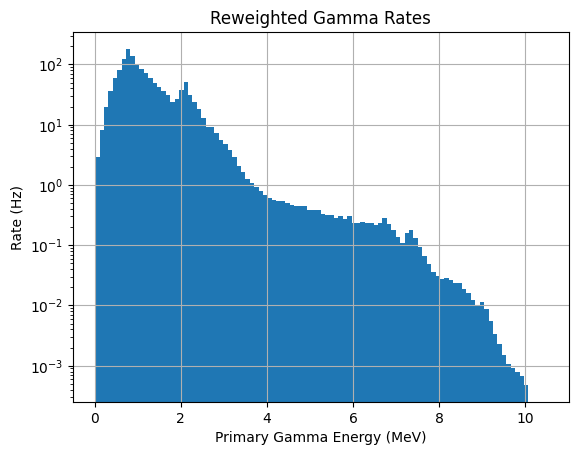

             EventID  TrackID  PDGCode  PrimaryEnergy  PrimaryPosX  \
0         30000000.0      1.0     22.0       2.788437       -510.0   
1         30000001.0      1.0     22.0       0.159717       -510.0   
2         30000002.0      1.0     22.0       0.990784       -510.0   
3         30000003.0      1.0     22.0       9.346932       -510.0   
4         30000004.0      1.0     22.0       1.370257       -510.0   
...              ...      ...      ...            ...          ...   
99999995  19999995.0      1.0     22.0       7.946372       -510.0   
99999996  19999996.0      1.0     22.0       3.015590       -510.0   
99999997  19999997.0      1.0     22.0       2.235590       -510.0   
99999998  19999998.0      1.0     22.0       6.297632       -510.0   
99999999  19999999.0      1.0     22.0       5.819500       -510.0   

          PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0         -476.468510   290.625752          0.672019         -0.170474   
1          

In [41]:
Emin, Emax = energy.min(), energy.max()
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=bin_edges)
print(counts_den)

fin_edges, weights = create_weights(rate, counts_den, edges)

df['weights'] = apply_weights(df['PrimaryEnergy'], fin_edges, weights)

plt.hist(df['PrimaryEnergy'], bins=edges, weights=df['weights'])
plt.xlabel('Primary Gamma Energy (MeV)')
plt.ylabel('Rate (Hz)')
plt.title('Reweighted Gamma Rates')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Reweighted_gamma_rates.pdf')
plt.show()

print(df)


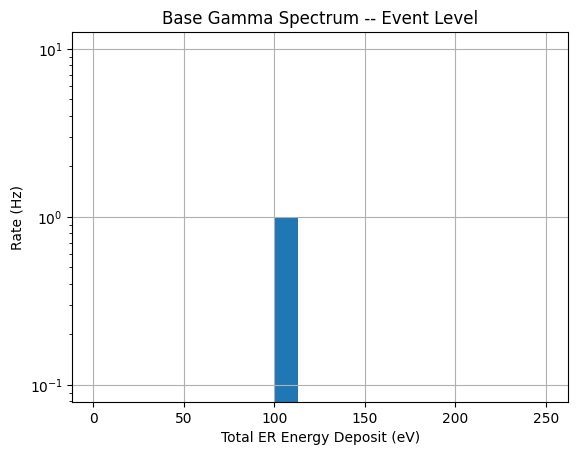

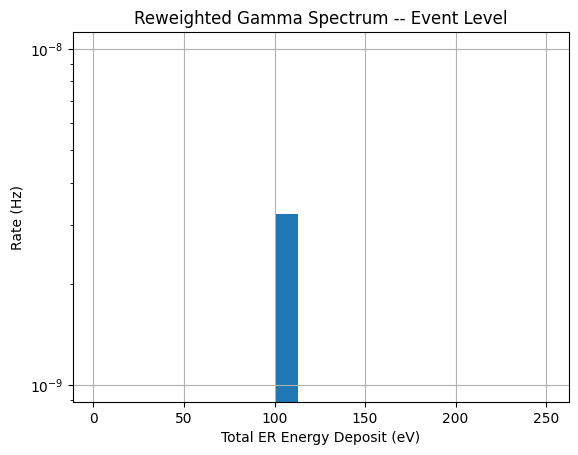

In [15]:
plt.hist(df['totalER']*1e6, bins=20, range=(1,250))
plt.xlabel('Total ER Energy Deposit (eV)')
plt.ylabel('Rate (Hz)')
plt.title('Base Gamma Spectrum -- Event Level')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Recoil_gamma_HFIR_base.pdf')
plt.show()

plt.hist(df['totalER']*1e6, bins=20, range=(1,250), weights=df['weights'])
plt.xlabel('Total ER Energy Deposit (eV)')
plt.ylabel('Rate (Hz)')
plt.title('Reweighted Gamma Spectrum -- Event Level')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Recoil_gamma_HFIR_reweighted.pdf')
plt.show()

In [42]:
merged_df5 = df.merge(df5, on=["EventID"], how="inner")

[1026398 1024822 1025292 1026915 1024598 1026699 1026413 1026421 1025580
 1027645 1026625 1026067 1025955 1025253 1026986 1026158 1026854 1025885
 1025209 1025536 1025584 1025400 1024329 1026145 1026612 1024683 1026587
 1025306 1026458 1025096 1025946 1026244 1027286 1026504 1026016 1027645
 1027421 1026022 1026013 1025000 1026994 1026382 1024965 1026936 1025666
 1025032 1025004 1026295 1026502 1027181 1025106 1024253 1025025 1026212
 1025441 1027596 1024735 1026976 1026918 1026191 1025134 1027650 1025527
 1026515 1025977 1025197 1026707 1025958 1024547 1026681 1026769 1027044
 1025295 1026923 1025259 1025378 1026680 1025851 1024364 1026790 1024870
 1026771 1026984 1026791 1026131 1026610 1025459 1024921 1027798 1025327
 1025694 1026449 1027103 1027004 1026499 1024969 1027566  337848       0
       0       0       0]


/tmp/ipykernel_374919/3353406073.py:4: RuntimeWarning: divide by zero encountered in divide
  w = np.divide(num, denom, out=None, where=True)


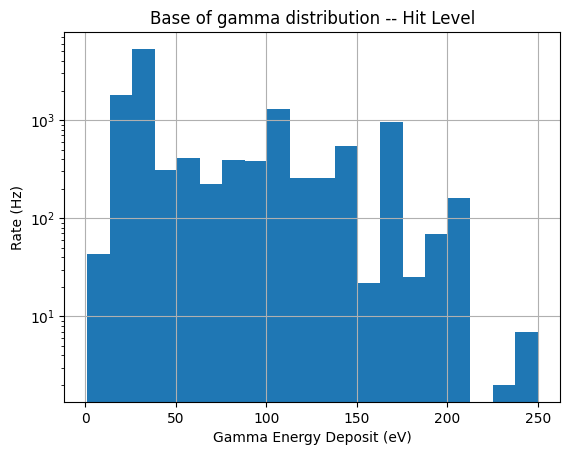

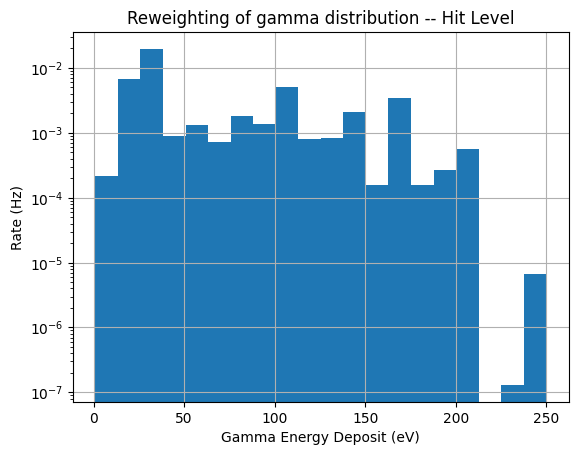

In [46]:
Emin, Emax = energy.min(), energy.max()
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=edges)
print(counts_den)

fin_edges, weights = create_weights(rate, counts_den, edges)

merged_df5['weights'] = apply_weights(merged_df5['PrimaryEnergy'], fin_edges, weights)

plt.hist(merged_df5['Edep']*1e6, bins=20, range=(1,250))
plt.xlabel('Gamma Energy Deposit (eV)')
plt.ylabel('Rate (Hz)')
plt.title('Base of gamma distribution -- Hit Level')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('gamma_base_hitlevel.pdf')
plt.show()

plt.hist(merged_df5['Edep']*1e6, bins=20, range=(1,250), weights=merged_df5['weights'])
plt.xlabel('Gamma Energy Deposit (eV)')
plt.ylabel('Rate (Hz)')
plt.title('Reweighting of gamma distribution -- Hit Level')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('gamma_reweighted_hitlevel.pdf')
plt.show()

In [47]:
#attempt to compute by wafer energy deposition
merged_df5['edep_channel'] = merged_df5.groupby(['EventID', 'CopyNumber'])["Edep"].transform("sum")
#print(merged_df5)
df_summed = merged_df5.drop_duplicates(subset=['EventID', 'CopyNumber'])
print(df_summed)

          EventID  TrackID_x  PDGCode_x  PrimaryEnergy  PrimaryPosX  \
0      30215075.0        1.0       22.0       6.421921       -510.0   
1      30243745.0        1.0       22.0       5.097093       -510.0   
22     30296317.0        1.0       22.0       6.833415       -510.0   
51     30317018.0        1.0       22.0       3.036891       -510.0   
69     30510787.0        1.0       22.0       9.475807       -510.0   
...           ...        ...        ...            ...          ...   
18292  19628941.0        1.0       22.0       5.945722       -510.0   
18297  19723520.0        1.0       22.0       9.712493       -510.0   
18299  19755856.0        1.0       22.0       2.742026       -510.0   
18310  19787395.0        1.0       22.0       5.902821       -510.0   
18328  19848787.0        1.0       22.0       4.245155       -510.0   

       PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0       196.137457   -29.136016          0.695033         -0.681947   
1    

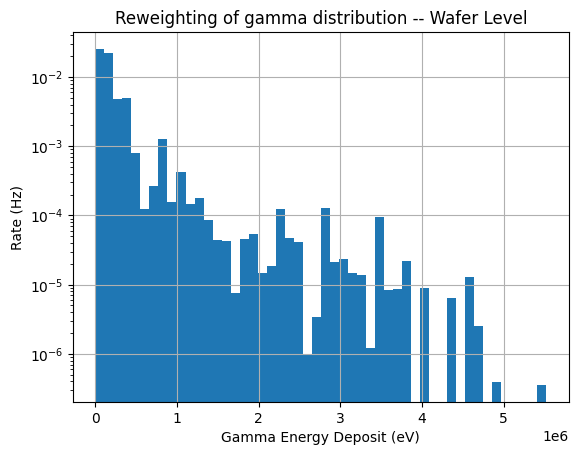

In [36]:
plt.hist(merged_df5['edep_channel']*1e6, bins=50, weights=merged_df5['weights'])
plt.xlabel('Gamma Energy Deposit (eV)')
plt.ylabel('Rate (Hz)')
plt.title('Reweighting of gamma distribution -- Wafer Level')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('gamma_reweighted_waferlevel.pdf')
plt.show()

In [45]:
#convert to /eV/HFIR-yr for gammas
per_ev = (150-1)/20 #bin width
Hz_to_HFIR_yr = 1.404e7 #seconds in 3900 hours, nominal HFIR-yr
merged_df5['weights'] = merged_df5['weights']*Hz_to_HFIR_yr/per_ev


/tmp/ipykernel_977137/3689519033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  masked_df_total['weights'] = masked_df_total['weights']/per_ev


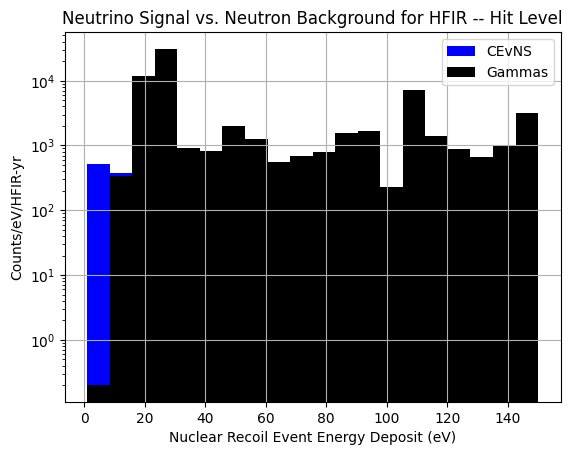

In [58]:
masked_df_total['weights'] = masked_df_total['weights']/per_ev
plt.hist(masked_df_total['totalNR']*1e6, bins=20, range=(1,150), label="CEvNS", color='blue', weights=masked_df_total['weights'])
plt.hist(merged_df5['Edep']*1e6, bins=20, range=(1,150), label="Gammas", color='black', weights=merged_df5['weights'])
plt.xlabel('Nuclear Recoil Event Energy Deposit (eV)')
plt.ylabel('Counts/eV/HFIR-yr')
plt.title('Neutrino Signal vs. Neutron Background for HFIR -- Hit Level')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('HFIR_CEvNS_gammas_reweighted.pdf')
plt.show()

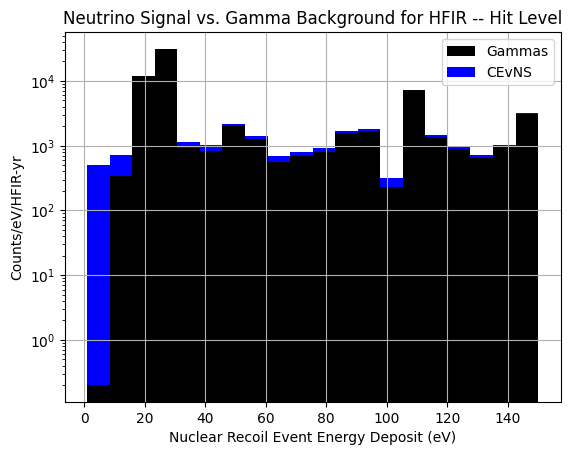

In [64]:
plt.hist([merged_df5['Edep']*1e6,masked_df_total['totalNR']*1e6], bins=20, range=(1,150), label=["Gammas", "CEvNS"], color=['black', 'blue'], stacked=True, weights=[merged_df5['weights'], masked_df_total['weights']])
#plt.hist(merged_df5['Edep']*1e6, bins=20, range=(1,150), label="Gammas", color='black', weights=merged_df5['weights'])
plt.xlabel('Nuclear Recoil Event Energy Deposit (eV)')
plt.ylabel('Counts/eV/HFIR-yr')
plt.title('Neutrino Signal vs. Gamma Background for HFIR -- Hit Level')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('HFIR_CEvNS_stacked_gammas_reweighted.pdf')
plt.show()

In [48]:
directory = "/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7424997/"
tree_name1 = "DetectorNeutrons"
tree_name2 = "Hits"
tree_name3 = "Primary"

pattern1 = f"{directory}/*.root:{tree_name1}"
pattern2 = f"{directory}/*.root:{tree_name2}"
pattern3 = f"{directory}/*.root:{tree_name3}"

dfs4 = []
dfs5 = []
dfs = []

print("Starting transfer of neutrons")
for chunk_dfs4 in uproot.iterate(pattern1,library="pd", step_size="250 MB"):
    dfs4.append(chunk_dfs4)
#print("neutrons complete, moving to hits")
#for chunk_dfs5 in uproot.iterate(pattern2,library="pd", step_size="250 MB"):
#    dfs5.append(chunk_dfs5)
print("hits complete, doing primaries")
for chunk_dfs in uproot.iterate(pattern3,library="pd", step_size="250 MB"):
    dfs.append(chunk_dfs)
print("transfer done, concatenating dataframes")
df4_neutrons = pd.concat(dfs4, ignore_index=True)
#print("done concat neutrons, concat hits")
#df5_neutrons = pd.concat(dfs5, ignore_index=True)
print("done concat hits, concat primaries")
df_neutrons = pd.concat(dfs, ignore_index=True)
print("Done.")

Starting transfer of neutrons
hits complete, doing primaries
transfer done, concatenating dataframes
done concat hits, concat primaries
Done.


In [49]:
neutron_rates = np.loadtxt("/N/project/phonon/jczettle/HFIR_near_neutrons.txt", delimiter=',')
energy = neutron_rates[:,0]
#extract gamma rates
rate = neutron_rates[:,1] #neutrons/MeV/s
print(rate)
print(energy)

rate = rate/rate.sum()
#bins_num = len(rate)

rate_neutron, bin_edges = np.histogram(energy, bins=energy, weights=rate)

print("Histogram values:", rate_neutron)
print("Bin edges:", bin_edges)

[2.98787427e-02 5.90220776e-04 2.28781177e-02 1.27159211e-02
 1.70562698e-02 7.86415698e-03 1.14280206e-02 7.06765534e-03
 4.61071328e-03 5.86294665e-03 6.92755066e-04 2.92864456e-03
 2.12586769e-03 5.74672334e-04 2.31855494e-04 8.86800822e-05
 3.46043292e-04 3.28051501e-04 3.36927323e-04 2.25747624e-04
 3.19409498e-04 1.77531475e-04 1.72854687e-04 1.19745960e-05
 9.60746245e-05 1.01343781e-04 1.09794279e-04 4.54957695e-05
 2.66739269e-05 2.39723243e-05 1.43390949e-04 4.31303129e-05
 2.96799912e-05 2.88981183e-05 5.94173179e-05 4.79909581e-05
 2.66739269e-05 2.39723243e-05 2.96799912e-05 1.13520021e-05
 1.16591440e-05 3.06871476e-06 1.57435058e-06 1.20547836e-06
 1.05484441e-06 9.48007109e-07 0.00000000e+00 0.00000000e+00]
[   1.0572886     1.18923811    1.32940073    1.48608281    1.68192432
    1.88015454    2.11479764    2.37872417    2.65907865    2.97247547
    3.34344011    3.73749521    4.23003622    4.75794431    5.35173529
    5.94557071    6.72910011    7.52218631    8.356857

[  63059   66096   74534   92620   94015  111484  125145  132589  148708
  175660  187643  232120  251163  282356  281994  371634  376676  395629
  521976  529829  592191  700705  789424  836493 1047272  935995 1237828
 1393726 1654281 1676251 1873546 2341974 2369445 2647930 2956762 3896506
 3326610 4402857 4676084 5850806 5914856 7399953 7488600 8862506 9969240
    3587 5136726]


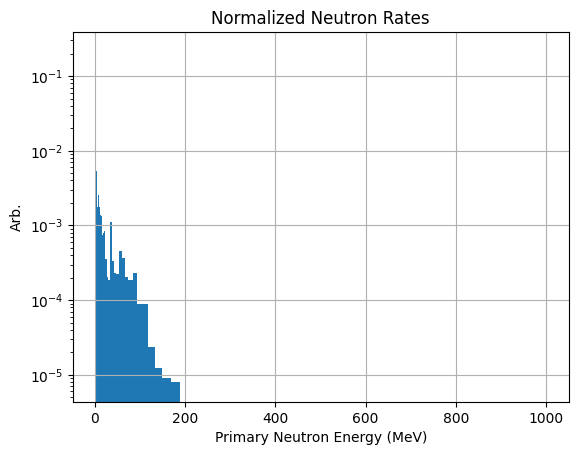

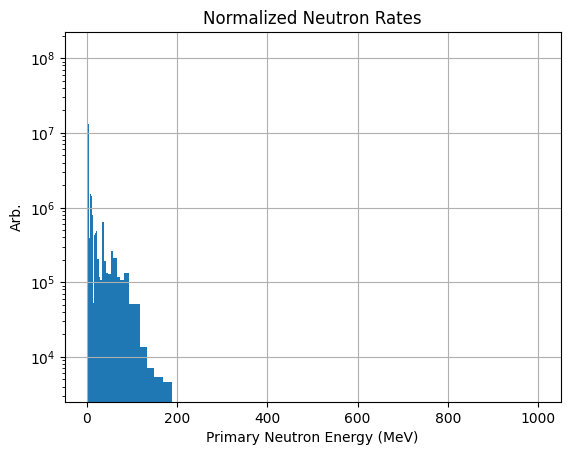

In [50]:
Emin, Emax = energy.min(), energy.max()
counts_den, edges = np.histogram(df_neutrons['PrimaryEnergy'], bins=bin_edges)
print(counts_den)

fin_edges, weights = create_weights(rate_neutron, counts_den, edges)

df_neutrons['weights'] = apply_weights(df_neutrons['PrimaryEnergy'], fin_edges, weights)

plt.hist(df_neutrons['PrimaryEnergy'], bins=edges, weights=df_neutrons['weights'])
plt.xlabel('Primary Neutron Energy (MeV)')
plt.ylabel('Arb.')
plt.title('Normalized Neutron Rates')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Reweighted_neutrons_rates.pdf')
plt.show()

df_neutrons['weights'] = df_neutrons['weights']*4.1e-3*1e4*1.404e7 #convert to /HFIR-yr using 1m gen plane 
plt.hist(df_neutrons['PrimaryEnergy'], bins=edges, weights=df_neutrons['weights'])
plt.xlabel('Primary Neutron Energy (MeV)')
plt.ylabel('Arb.')
plt.title('Normalized Neutron Rates')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Reweighted_neutrons_rates_absnorm.pdf')
plt.show()

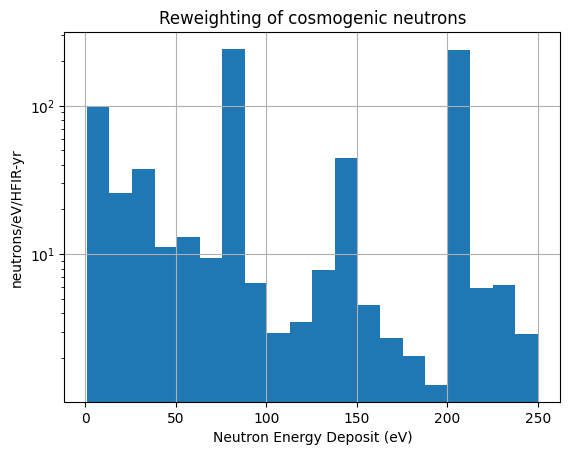

In [23]:
plt.hist(df_neutrons['totalNR']*1e6, bins=20, range=(1,250), weights=df_neutrons['weights'])
plt.xlabel('Neutron Energy Deposit (eV)')
plt.ylabel('neutrons/eV/HFIR-yr')
plt.title('Reweighting of cosmogenic neutrons')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('neutron_reweighted_totalNR.pdf')
plt.show()

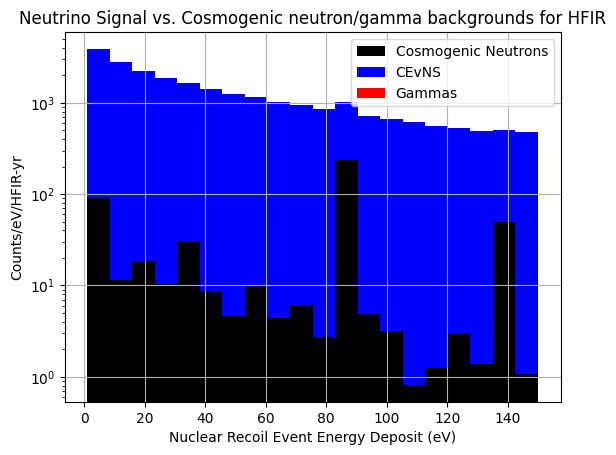

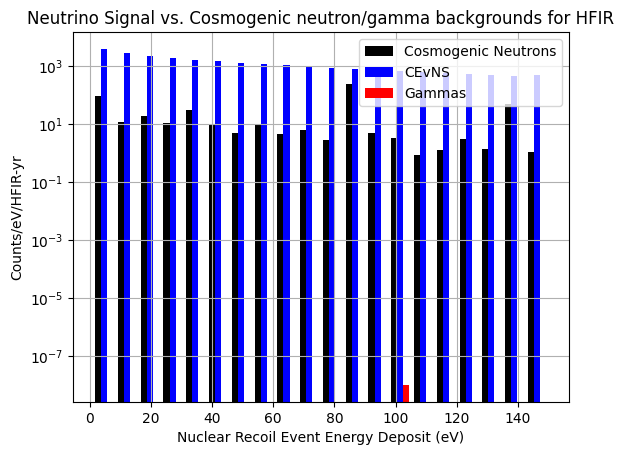

In [73]:
plt.hist([df_neutrons['totalNR']*1e6, masked_df_total['totalNR']*1e6, merged_df5['edep_channel']*1e6], bins=20, range=(1,150), label=["Cosmogenic Neutrons", "CEvNS", "Gammas"], color=['black', 'blue', 'red'], stacked=True, weights=[df_neutrons['weights'], masked_df_total['weights'], merged_df5['weights']])
#plt.hist(merged_df5['Edep']*1e6, bins=20, range=(1,150), label="Gammas", color='black', weights=merged_df5['weights'])
plt.xlabel('Nuclear Recoil Event Energy Deposit (eV)')
plt.ylabel('Counts/eV/HFIR-yr')
plt.title('Neutrino Signal vs. Cosmogenic neutron/gamma backgrounds for HFIR')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('HFIR_CEvNS_stacked_neutronsgammas_reweighted_color.pdf')
plt.show()

plt.hist([df_neutrons['totalNR']*1e6, masked_df_total['totalNR']*1e6, merged_df5['edep_channel']*1e6], bins=20, range=(1,150), label=["Cosmogenic Neutrons", "CEvNS", "Gammas"], color=['black', 'blue', 'red'], stacked=False, weights=[df_neutrons['weights'], masked_df_total['weights'], merged_df5['weights']])
#plt.hist(merged_df5['Edep']*1e6, bins=20, range=(1,150), label="Gammas", color='black', weights=merged_df5['weights'])
plt.xlabel('Nuclear Recoil Event Energy Deposit (eV)')
plt.ylabel('Counts/eV/HFIR-yr')
plt.title('Neutrino Signal vs. Cosmogenic neutron/gamma backgrounds for HFIR')
plt.yscale('log')
plt.legend()
plt.grid()
#plt.savefig('HFIR_CEvNS_unstacked_neutronsgammas_reweighted.pdf')
plt.show()

In [75]:
#number of events in signal/background greater than 10 eV (set 500 eV max)
cond_nu = masked_df_total['totalNR']*1e6 > 10 
cond_nu2 = masked_df_total['totalNR']*1e6 < 500
cond_n = df_neutrons['totalNR']*1e6 > 10
cond_n2 = df_neutrons['totalNR']*1e6 <= 1000

signal = masked_df_total[cond_nu & cond_nu2]['weights'].sum()
print(f"Signal Events: {signal}")
background = df_neutrons[cond_n & cond_n2]['weights'].sum()
print(f"Background Events: {background}")
snr = signal/background
print(f"Signal to Noise for 10 eV threshold: {snr}")

#number of events in signal/background greater than 100 eV (set 500 eV max)
cond_nu = masked_df_total['totalNR']*1e6 > 100 
cond_nu2 = masked_df_total['totalNR']*1e6 < 500
cond_n = df_neutrons['totalNR']*1e6 > 100
cond_n2 = df_neutrons['totalNR']*1e6 <= 1000

signal = masked_df_total[cond_nu & cond_nu2]['weights'].sum()
print(f"Signal Events: {signal}")
background = df_neutrons[cond_n & cond_n2]['weights'].sum()
print(f"Background Events: {background}")
snr = signal/background
print(f"Signal to Noise for 100 eV threshold: {snr}")

#number of events in signal/background greater than 1000 eV (set 2000 eV max)
cond_nu = masked_df_total['totalNR']*1e6 > 1000 
cond_nu2 = masked_df_total['totalNR']*1e6 < 2000
cond_n = df_neutrons['totalNR']*1e6 >= 1000
cond_n2 = df_neutrons['totalNR']*1e6 <= 5000

signal = masked_df_total[cond_nu & cond_nu2]['weights'].sum()
print(f"Signal Events: {signal}")
background = df_neutrons[cond_n & cond_n2]['weights'].sum()
print(f"Background Events: {background}")
snr = signal/background
print(f"Signal to Noise for 1 keV threshold: {snr}")


Signal Events: 19714.5625
Background Events: 986.2095132927636
Signal to Noise for 10 eV threshold: 19.99023760597976
Signal Events: 3582.1484141552514
Background Events: 637.6948959516511
Signal to Noise for 100 eV threshold: 5.6173390078800995
Signal Events: 0.0
Background Events: 2250.6072678200057
Signal to Noise for 1 keV threshold: 0.0


/tmp/ipykernel_374919/2819886237.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  masked_df_total['HBARphononsNR'] = masked_df_total['totalNR']/debye_to_meV*1e9*debye_to_HBAR


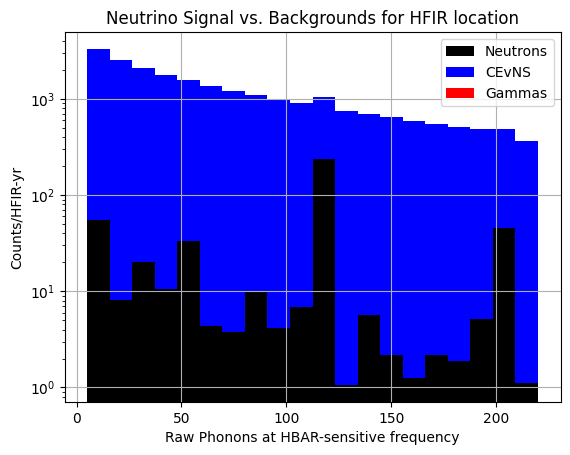

In [72]:
#convert to raw phonons at HBAR frequency
debye_to_meV = 48.34 #convert Debye frequency to energy in eV
debye_to_HBAR = 0.07 #fraction of Debye phonons that produce a phonon at the HBAR frequency (4 +/- 0.01 GHz) 
#create dataframe entry for the totalNR energy converted into phonons and plot

masked_df_total['HBARphononsNR'] = masked_df_total['totalNR']/debye_to_meV*1e9*debye_to_HBAR
#print(masked_df_total['totalNR'])
#print(masked_df_total['HBARphononsNR'])
df_neutrons['HBARphononsNR'] = df_neutrons['totalNR']/debye_to_meV*1e9*debye_to_HBAR
merged_df5['HBARphonons'] = merged_df5['edep_channel']/debye_to_meV*1e9*debye_to_HBAR

plt.hist([df_neutrons['HBARphononsNR'], masked_df_total['HBARphononsNR'], merged_df5['HBARphonons']], bins=20, range=(5,220), label=["Neutrons", "CEvNS", "Gammas"], color=['black', 'blue', 'red'], stacked=True, weights=[df_neutrons['weights'], masked_df_total['weights'], merged_df5['weights']])
#plt.hist(masked_df_total['HBARphononsNR'], bins=20, range=(100,1500), label="CEvNS", color='blue', weights=masked_df_total['weights'])
plt.xlabel('Raw Phonons at HBAR-sensitive frequency')
plt.ylabel('Counts/HFIR-yr')
plt.title('Neutrino Signal vs. Backgrounds for HFIR location')
plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig('HFIR_CEvNS_stacked_phononscale.pdf')
plt.show()